In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error
import math

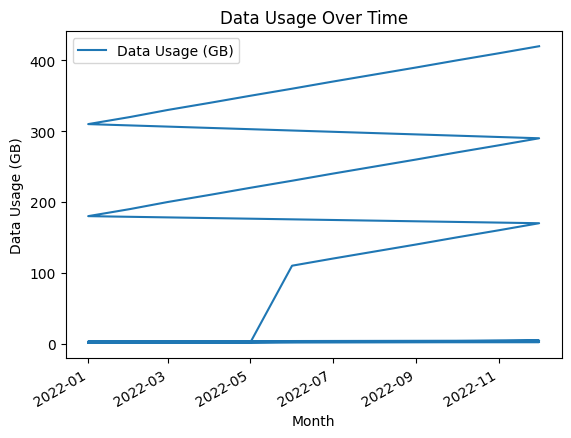

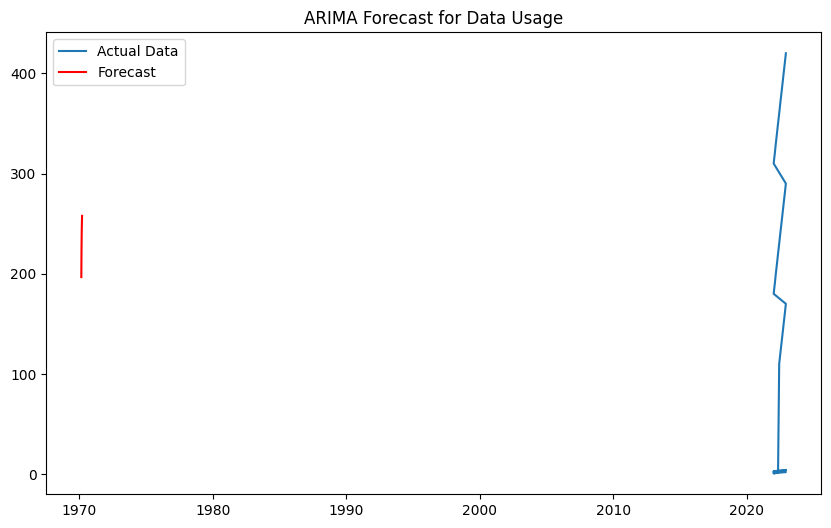

RMSE: 90.15950641975114


In [31]:
data = pd.read_csv('data_usage_monthly.csv', delimiter=',', header=0, encoding='utf-8')
df = pd.DataFrame(data)
df['Month'] = pd.to_datetime(df['Month'])
# Set the month as index
df.set_index('Month', inplace=True)

# Visualize the data
df.plot()
plt.title('Data Usage Over Time')
plt.ylabel('Data Usage (GB)')
plt.show()

# Train/Test split
train, test = train_test_split(df, test_size=0.3, shuffle=False)

# Fit ARIMA model
model = ARIMA(train['Data Usage (GB)'], order=(1, 1, 1))  # ARIMA(p,d,q)
model_fit = model.fit()

# Forecasting
forecast = model_fit.forecast(steps=len(test))
#forecast = pd.Series(forecast, index=test.index) # this was suggested by ChatGPT, but does not work

# Plotting the forecast
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Data Usage (GB)'], label='Actual Data')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast for Data Usage')
plt.legend()
plt.show()

# Drop NaN values if they exist
test_clean = test.dropna(subset=['Data Usage (GB)'])
forecast_clean = forecast.dropna()

# Ensure the lengths are the same
if len(test_clean) == len(forecast_clean):
    rmse = math.sqrt(mean_squared_error(test_clean['Data Usage (GB)'], forecast_clean))
    print(f'RMSE: {rmse}')
else:
    print(f'Error: The lengths of test data ({len(test_clean)}) and forecast ({len(forecast_clean)}) are not the same.')

In [35]:
# trying to reduce RMSE
# Example of testing different ARIMA orders
p_values = [0, 1, 2]
d_values = [0, 1, 2]
q_values = [0, 1, 2]

best_rmse = float('inf')
best_order = (0, 0, 0)

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train['Data Usage (GB)'], order=(p, d, q))
                model_fit = model.fit()
                forecast = model_fit.forecast(steps=3)
                rmse = np.sqrt(mean_squared_error(test['Data Usage (GB)'][:3], forecast))
                print(f'Order: ({p},{d},{q}) - RMSE: {rmse}')
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_order = (p, d, q)
            except:
                continue

print(f'Best ARIMA order: {best_order} with RMSE: {best_rmse}')

Order: (0,0,0) - RMSE: 181.13812010241872
Order: (0,0,1) - RMSE: 158.87139995252548
Order: (0,0,2) - RMSE: 138.59807900470915
Order: (0,1,0) - RMSE: 21.602468994692867
Order: (0,1,1) - RMSE: 20.65164684351385
Order: (0,1,2) - RMSE: 19.43956339592308
Order: (0,2,0) - RMSE: 0.0
Order: (0,2,1) - RMSE: 1.8291925664551822
Order: (0,2,2) - RMSE: 1.806586327784131
Order: (1,0,0) - RMSE: 25.815021210272075
Order: (1,0,1) - RMSE: 25.952669716135826
Order: (1,0,2) - RMSE: 25.482953093524323
Order: (1,1,0) - RMSE: 20.15456973953655
Order: (1,1,1) - RMSE: 8.189414299639195
Order: (1,1,2) - RMSE: 8.382526850048263
Order: (1,2,0) - RMSE: 0.0
Order: (1,2,1) - RMSE: 1.8067206194618208
Order: (1,2,2) - RMSE: 1.8469255954322625
Order: (2,0,0) - RMSE: 25.92440984170803
Order: (2,0,1) - RMSE: 15.700004060110212
Order: (2,0,2) - RMSE: 22.21080253381581
Order: (2,1,0) - RMSE: 18.08943037943412
Order: (2,1,1) - RMSE: 8.37350252212049
Order: (2,1,2) - RMSE: 8.58188421050058
Order: (2,2,0) - RMSE: 0.0
Order: (